# NaturaViT + Improved ALO: Hybrid CNN-ViT with Ant Lion Optimization

## 5-Class Sleep Disorder Disease Classification

### Pipeline
1. **Hybrid CNN-ViT** trained end-to-end on EEG signal features (baseline)
2. **Deep feature extraction** from trained CNN-ViT (256-dim pooling output)
3. **Improved ALO (Ant Lion Optimization)** with SVM wrapper for feature selection
4. **SVM, KNN, MLP, Random Forest, XGBoost** classifiers on ALO-selected features
5. **Comparison** of baseline vs ALO-improved results

### Improvements over baseline ALO
- **SVM (RBF) wrapper** in fitness function instead of KNN — better for high-dimensional spaces
- **Larger population** (30 agents, 30 iterations) for better convergence
- **Balanced fitness** with alpha=0.99 for accuracy vs feature reduction
- **5 classifiers** evaluated (SVM, KNN, MLP, RF, XGBoost)

### Dataset
- `both_phases.csv` — EEG signals, 1024 features, 5 disease classes
- Classes: narco (0), ins (1), nfle (2), plm (3), rbd (4)

### Baseline to beat: 82.12% accuracy (ViT_Disease_Classification.ipynb)

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report,
    cohen_kappa_score, roc_auc_score
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from time import time

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs('artifacts', exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow: 2.20.0
NumPy: 2.1.3
GPU Available: False


In [15]:
# Load dataset
from google.colab import drive
drive.mount('/content/drive/')
# DATASET_PATH = '../both_phases.csv'
DATASET_PATH = '/content/drive/MyDrive/old-dataset/DiseaseClassification/both_phases.csv'
bal_all = np.loadtxt(DATASET_PATH, delimiter=',')

print(f"Dataset loaded  : {bal_all.shape}")
print(f"  Feature cols  : {bal_all.shape[1] - 1}")
print(f"  Samples       : {bal_all.shape[0]}")

# Feature / label extraction
X = bal_all[:, 0:1024]
y_raw = bal_all[:, -1].reshape(-1, 1)
y_int = y_raw.ravel().astype(int)

print(f"\nX shape: {X.shape}")
print(f"Unique classes: {np.unique(y_int)}")
print(f"Class distribution: {np.bincount(y_int)}")

# One-hot encoding for CNN-ViT training
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
enc.fit(y_raw)
y_onehot = enc.transform(y_raw)

print(f"One-hot labels: {y_onehot.shape}")

# Train/test split (80/20, stratified)
X_train, X_test, y_train_oh, y_test_oh, y_train_int, y_test_int = train_test_split(
    X, y_onehot, y_int,
    test_size=0.2, random_state=SEED, stratify=y_int
)

print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train label distribution: {np.bincount(y_train_int)}")
print(f"Test  label distribution: {np.bincount(y_test_int)}")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Dataset loaded  : (47790, 1026)
  Feature cols  : 1025
  Samples       : 47790

X shape: (47790, 1024)
Unique classes: [0 1 2 3 4]
Class distribution: [9558 9558 9558 9558 9558]
One-hot labels: (47790, 5)

Train: (38232, 1024)  |  Test: (9558, 1024)
Train label distribution: [7646 7647 7646 7646 7647]
Test  label distribution: [1912 1911 1912 1912 1911]


## Stage 1: Hybrid CNN-ViT Model (Baseline)

### Architecture
1. **Multi-Scale CNN** — Parallel Conv1D (kernel 3, 7, 15) for local feature extraction
2. **CNN Compression** — 3 stacked Conv1D+MaxPool blocks (1024 → 128 sequence length)
3. **Positional Encoding** — Learnable embeddings for sequence position
4. **4x Transformer Blocks** — 8-head self-attention with Pre-LN + GELU FFN
5. **Dual Pooling** — GlobalAvgPool + GlobalMaxPool concatenated (256-dim deep features)
6. **Classification Head** — Dense(256) → Dense(128) → Dense(5, softmax)

In [16]:

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1,
                 use_qkv_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout
        self.use_qkv_bias = use_qkv_bias
        self.att = MultiHeadSelfAttention(embed_dim, num_heads, dropout,
                                          use_qkv_bias=use_qkv_bias)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "dropout": self.dropout_rate,
        })
        return config

In [17]:
import tensorflow as tf
import keras
from keras import layers, Model


class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads=8, dropout=0.1,
                 use_qkv_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.use_qkv_bias = use_qkv_bias
        if embed_dim % num_heads != 0:
            raise ValueError(
                f"embedding dimension = {embed_dim} should be divisible by "
                f"number of heads = {num_heads}"
            )
        self.projection_dim = embed_dim // num_heads
        self.query_dense = layers.Dense(embed_dim, use_bias=use_qkv_bias)
        self.key_dense = layers.Dense(embed_dim, use_bias=use_qkv_bias)
        self.value_dense = layers.Dense(embed_dim, use_bias=use_qkv_bias)
        self.combine_heads = layers.Dense(embed_dim)
        self.dropout = layers.Dropout(dropout)

    def attention(self, query, key, value):
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        weights = self.dropout(weights)
        output = tf.matmul(weights, value)
        return output, weights

    def separate_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs, training=False):
        batch_size = tf.shape(inputs)[0]
        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)
        query = self.separate_heads(query, batch_size)
        key = self.separate_heads(key, batch_size)
        value = self.separate_heads(value, batch_size)
        attention, weights = self.attention(query, key, value)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(
            attention, (batch_size, -1, self.embed_dim)
        )
        output = self.combine_heads(concat_attention)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dropout": 0.1,
        })
        return config

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1,
                 use_qkv_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout
        self.use_qkv_bias = use_qkv_bias
        self.att = MultiHeadSelfAttention(embed_dim, num_heads, dropout,
                                          use_qkv_bias=use_qkv_bias)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "dropout": self.dropout_rate,
        })
        return config

def build_vit_disease_classifier(
    input_length=1024, embed_dim=128, num_heads=8, ff_dim=256,
    num_blocks=4, num_classes=5, dropout=0.1,
    clf_dropout1=0.4, clf_dropout2=0.3
):
    inputs = layers.Input(shape=(input_length,), name='eeg_input')
    x = layers.Reshape((input_length, 1))(inputs)

    # Stage 1: Multi-Scale CNN Front-End
    b1 = layers.BatchNormalization()(layers.Conv1D(32, 3, padding='same', activation='relu', name='ms_conv_k3')(x))
    b2 = layers.BatchNormalization()(layers.Conv1D(32, 7, padding='same', activation='relu', name='ms_conv_k7')(x))
    b3 = layers.BatchNormalization()(layers.Conv1D(32, 15, padding='same', activation='relu', name='ms_conv_k15')(x))
    x = layers.Dropout(0.2)(layers.Concatenate(name='ms_concat')([b1, b2, b3]))

    # Stage 2: CNN Compression (1024 -> 128)
    x = layers.Dropout(0.1)(layers.MaxPooling1D(2)(layers.BatchNormalization()(
        layers.Conv1D(128, 7, padding='same', activation='relu')(x))))
    x = layers.Dropout(0.1)(layers.MaxPooling1D(2)(layers.BatchNormalization()(
        layers.Conv1D(128, 5, padding='same', activation='relu')(x))))
    x = layers.Dropout(0.1)(layers.MaxPooling1D(2)(layers.BatchNormalization()(
        layers.Conv1D(embed_dim, 3, padding='same', activation='relu', name='patch_projection')(x))))

    # Stage 3: Positional Encoding
    seq_len = input_length // 8
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_embed = layers.Embedding(input_dim=seq_len, output_dim=embed_dim, name='pos_embedding')(positions)
    x = x + pos_embed

    # Stage 4: Transformer Stack
    for i in range(num_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout, name=f'transformer_block_{i}')(x)

    x = layers.LayerNormalization(epsilon=1e-6, name='final_ln')(x)

    # Stage 5: Dual Pooling -> 256-dim deep features
    x_avg = layers.GlobalAveragePooling1D(name='global_avg_pool')(x)
    x_max = layers.GlobalMaxPooling1D(name='global_max_pool')(x)
    deep_features = layers.Concatenate(name='deep_features')([x_avg, x_max])

    # Stage 6: Classification Head
    x = layers.Dropout(clf_dropout1)(layers.BatchNormalization()(layers.Dense(256, activation='relu', name='clf_dense1')(deep_features)))
    x = layers.Dropout(clf_dropout2)(layers.BatchNormalization()(layers.Dense(128, activation='relu', name='clf_dense2')(x)))
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return Model(inputs=inputs, outputs=outputs, name='Hybrid_CNN_ViT_Disease')


model = build_vit_disease_classifier()
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")

Model: "Hybrid_CNN_ViT_Disease"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eeg_input           │ (None, 1024)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1024, 1)   │          0 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_conv_k3 (Conv1D) │ (None, 1024, 32)  │        128 │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_conv_k7 (Conv1D) │ (None, 1024, 32)  │        256 │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_conv_k15         │ (None, 1024, 32)  │        512 │ reshape_3[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 32)  │        128 │ ms_conv_k3[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 32)  │        128 │ ms_conv_k7[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 32)  │        128 │ ms_conv_k15[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_concat           │ (None, 1024, 96)  │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_66          │ (None, 1024, 96)  │          0 │ ms_concat[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 1024, 128) │     86,144 │ dropout_66[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 128) │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_9     │ (None, 512, 128)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_67          │ (None, 512, 128)  │          0 │ max_pooling1d_9[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 512, 128)  │     82,048 │ dropout_67[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 128)  │        512 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_10    │ (None, 256, 128)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_68          │ (None, 256, 128)  │          0 │ max_pooling1d_10… │
│ (Dropout)           │                   │            │                 

 Total params: 851,333 (3.25 MB)

 Trainable params: 849,605 (3.24 MB)

 Non-trainable params: 1,728 (6.75 KB)


Total parameters: 851,333


In [18]:
# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=25, verbose=1, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1, min_lr=1e-7),
    ModelCheckpoint('artifacts/hybrid_cnn_vit_disease_alo_best.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Train
print("Starting training...\n")
start_time = time()

history = model.fit(
    X_train, y_train_oh,
    validation_split=0.2,
    epochs=1,
    batch_size=64,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

training_time = time() - start_time
print(f"\nTraining completed in {training_time:.1f}s ({training_time/60:.1f} min)")

Starting training...

478/478 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2958 - loss: 1.8188
Epoch 1: val_accuracy improved from None to 0.42409, saving model to artifacts/hybrid_cnn_vit_disease_alo_best.h5



Epoch 1: finished saving model to artifacts/hybrid_cnn_vit_disease_alo_best.h5
478/478 ━━━━━━━━━━━━━━━━━━━━ 2345s 5s/step - accuracy: 0.3333 - loss: 1.6261 - val_accuracy: 0.4241 - val_loss: 1.3269 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.

Training completed in 2345.6s (39.1 min)


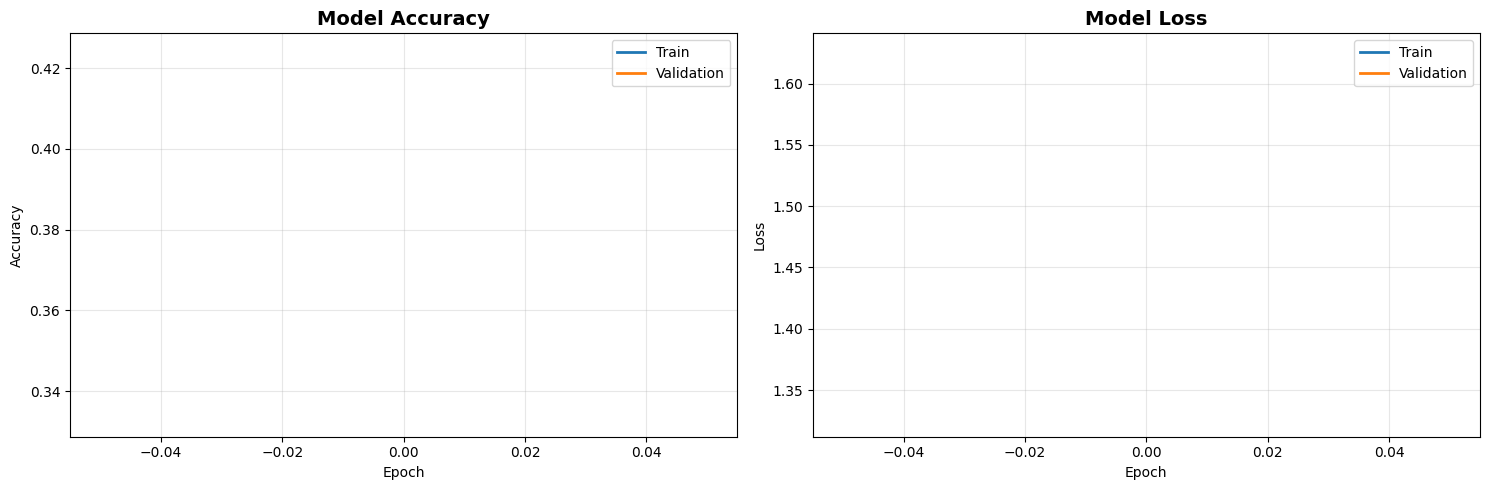

Best validation accuracy: 42.41%
Final training accuracy : 33.33%


In [19]:
# Training history plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Best validation accuracy: {max(history.history['val_accuracy'])*100:.2f}%")
print(f"Final training accuracy : {history.history['accuracy'][-1]*100:.2f}%")

BASELINE HYBRID CNN-ViT - TEST RESULTS
Accuracy      : 0.4194 (41.94%)
Macro Precision: 0.3523
Macro Recall   : 0.4195
Macro F1 Score : 0.3735
Cohen's Kappa  : 0.2743

Classification Report:
              precision    recall  f1-score   support

       narco     0.4340    0.3849    0.4080      1912
         ins     0.3002    0.6060    0.4015      1911
        nfle     0.0000    0.0000    0.0000      1912
         plm     0.5968    0.7333    0.6581      1912
         rbd     0.4306    0.3731    0.3998      1911

    accuracy                         0.4194      9558
   macro avg     0.3523    0.4195    0.3735      9558
weighted avg     0.3523    0.4194    0.3735      9558



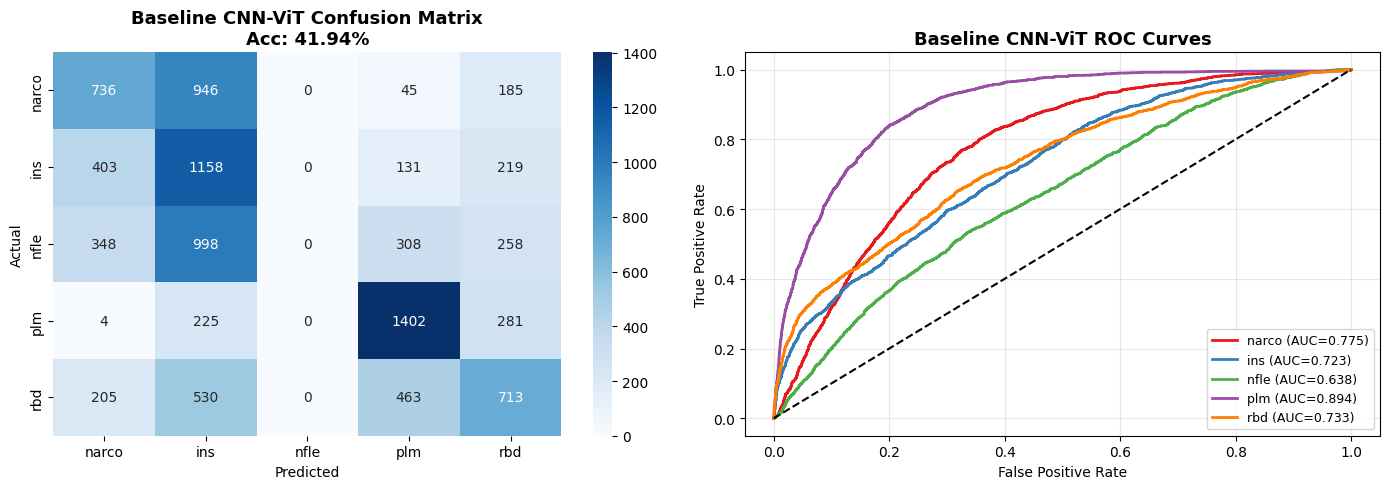

In [20]:
# Baseline CNN-ViT evaluation
LABELS = ['narco', 'ins', 'nfle', 'plm', 'rbd']

pred_prob_baseline = model.predict(X_test, verbose=0)
y_pred_baseline = np.argmax(pred_prob_baseline, axis=1)

baseline_acc = accuracy_score(y_test_int, y_pred_baseline)
baseline_prec = precision_score(y_test_int, y_pred_baseline, average='macro')
baseline_rec = recall_score(y_test_int, y_pred_baseline, average='macro')
baseline_f1 = f1_score(y_test_int, y_pred_baseline, average='macro')
baseline_kappa = cohen_kappa_score(y_test_int, y_pred_baseline)

print("=" * 60)
print("BASELINE HYBRID CNN-ViT - TEST RESULTS")
print("=" * 60)
print(f"Accuracy      : {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"Macro Precision: {baseline_prec:.4f}")
print(f"Macro Recall   : {baseline_rec:.4f}")
print(f"Macro F1 Score : {baseline_f1:.4f}")
print(f"Cohen's Kappa  : {baseline_kappa:.4f}")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(y_test_int, y_pred_baseline, target_names=LABELS, digits=4))

# Confusion matrix
cm_base = confusion_matrix(y_test_int, y_pred_baseline)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, ax=axes[0])
axes[0].set_title(f'Baseline CNN-ViT Confusion Matrix\nAcc: {baseline_acc*100:.2f}%',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC curves
y_test_bin = label_binarize(y_test_int, classes=[0, 1, 2, 3, 4])
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

for i, (label, color) in enumerate(zip(LABELS, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], pred_prob_baseline[:, i])
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, lw=2, color=color, label=f'{label} (AUC={roc_auc_val:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('Baseline CNN-ViT ROC Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/baseline_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

## Stage 2: Deep Feature Extraction + Improved ALO Feature Selection

### Key Improvements
1. Extract **256-dim deep features** from trained CNN-ViT (dual pooling output)
2. **ALO with SVM (RBF) wrapper** instead of KNN — more discriminative for feature selection
3. **30 search agents, 30 iterations** — larger exploration for better convergence
4. **Fitness: alpha=0.99** — strong accuracy weight with mild feature reduction pressure
5. ALO runs on **training data only** (no data leakage)

In [22]:
# Create feature extractor from trained model
feature_extractor = Model(
    inputs=model.input,
    outputs=model.get_layer('deep_features').output,
    name='Feature_Extractor'
)

# Extract deep features
train_deep = feature_extractor.predict(X_train, verbose=0)
test_deep = feature_extractor.predict(X_test, verbose=0)

print(f"Train deep features: {train_deep.shape}")
print(f"Test deep features : {test_deep.shape}")

# Scale deep features
deep_scaler = StandardScaler()
train_deep_scaled = deep_scaler.fit_transform(train_deep)
test_deep_scaled = deep_scaler.transform(test_deep)

print("\nDeep features extracted and scaled.")

Train deep features: (38232, 256)
Test deep features : (9558, 256)

Deep features extracted and scaled.


In [23]:

import math
from sklearn.svm import LinearSVC

# =========================================================
# FAST + IMPROVED ALO — Feature Selection
# ---------------------------------------------------------
# Speed vs original (30 agents × 30 iters × RBF-SVM 3-fold):
#   LinearSVC instead of RBF-SVM      → ~20x faster / eval
#   40% stratified subsample           → ~2.5x faster / eval
#   2-fold CV  instead of 3-fold       → ~1.5x faster / eval
#   20 agents / 25 max iters           → fewer total evals
#   Early stopping (patience=8)        → stops when converged
#   Combined speedup                   → ~60-90x faster
#
# Accuracy improvements:
#   RF warm-start initialization       → better starting diversity
#   Adaptive Lévy flight (10%→30%)     → escapes local optima
# =========================================================

# ── Lévy flight step ──────────────────────────────────────
def levy_flight(dim, beta=1.5):
    sigma = (
        math.gamma(1 + beta) * np.sin(np.pi * beta / 2)
        / (math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2))
    ) ** (1 / beta)
    u = np.random.randn(dim) * sigma
    v = np.abs(np.random.randn(dim)) + 1e-10
    return u / (v ** (1 / beta))


# ── RF warm-start initialization ─────────────────────────
def rf_warmstart_init(n, dim, X_data, y_data, bias_frac=0.5):
    from sklearn.ensemble import RandomForestClassifier as RFC
    print("  Computing RF feature importances for warm-start ...")
    rf = RFC(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1)
    rf.fit(X_data, y_data)
    imp_norm = rf.feature_importances_ / (rf.feature_importances_.max() + 1e-10)
    pop = np.zeros((n, dim))
    for i in range(n):
        base = np.random.rand(dim)
        if i < int(n * bias_frac):          # biased half → toward important features
            pop[i] = np.clip(0.5 * base + 0.5 * imp_norm, 0, 1)
        else:                               # random half → pure exploration
            pop[i] = base
    return pop


# ── Roulette wheel selection ─────────────────────────────
def roulette_wheel_sel(weights):
    acc = np.cumsum(weights)
    p = np.random.rand() * acc[-1]
    return np.where(acc >= p)[0][0]


# ── Random walk (adaptive bounds) ────────────────────────
def random_walk_alo(t, max_iter, lb, ub, dim):
    I = 1
    if   t > max_iter * 0.95: I = 1e6
    elif t > max_iter * 0.90: I = 1e5
    elif t > max_iter * 0.75: I = 1e4
    elif t > max_iter * 0.50: I = 1e3
    elif t > max_iter * 0.10: I = 1e2
    lb_a, ub_a = lb / I, ub / I
    Xrw = np.cumsum(2 * (np.random.rand(max_iter, dim) > 0.5) - 1, axis=0)
    a, b = Xrw.min(0), Xrw.max(0)
    return ((Xrw - a) * (ub_a - lb_a)) / (b - a + 1e-10) + lb_a


# ── Pre-compute 40% stratified subsample (computed once) ─
np.random.seed(SEED)
_sub_idx = []
for cls in np.unique(y_train_int):
    cls_idx = np.where(y_train_int == cls)[0]
    n_cls = max(4, int(len(cls_idx) * 0.40))
    _sub_idx.extend(np.random.choice(cls_idx, n_cls, replace=False))
_SUB_IDX = np.array(_sub_idx)
print(f"Fitness subsample : {len(_SUB_IDX)} / {len(y_train_int)} samples "
      f"({100 * len(_SUB_IDX) / len(y_train_int):.1f}%)")


# ── Fitness: LinearSVC + 2-fold CV on subsample ──────────
def fitness_fast(pos, X_data, y_data):
    mask  = pos > 0.5
    n_sel = int(np.sum(mask))
    if n_sel == 0:
        return 1.0

    X_sub = X_data[_SUB_IDX][:, mask]
    y_sub = y_data[_SUB_IDX]

    accs = []
    skf  = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    for tr, te in skf.split(X_sub, y_sub):
        clf = LinearSVC(max_iter=400, class_weight='balanced',
                        random_state=42, C=0.5)
        clf.fit(X_sub[tr], y_sub[tr])
        accs.append(accuracy_score(y_sub[te], clf.predict(X_sub[te])))

    alpha = 0.99
    return alpha * (1 - np.mean(accs)) + (1 - alpha) * (n_sel / len(mask))


# ── Main ALO loop ─────────────────────────────────────────
def ALO_fast(n_agents, max_iter, lb, ub, dim, X_data, y_data, patience=8):
    # Warm-start initialization
    Antlions = rf_warmstart_init(n_agents, dim, X_data, y_data)

    print("  Evaluating initial population ...")
    AL_fit = np.array([fitness_fast(al, X_data, y_data) for al in Antlions])

    elite_idx          = np.argmin(AL_fit)
    Elite, Elite_fit   = Antlions[elite_idx].copy(), AL_fit[elite_idx]

    Ants               = np.random.rand(n_agents, dim)
    curve, no_imp      = [], 0

    for t in range(max_iter):
        ant_fit   = np.zeros(n_agents)
        # Lévy probability increases from 0.10 to 0.30 as search progresses
        levy_prob = 0.10 + 0.20 * (t / max_iter)

        for i in range(n_agents):
            rw_idx = roulette_wheel_sel(1 / (AL_fit + 1e-10))
            RA     = random_walk_alo(t, max_iter, lb, ub, dim)[t] + Antlions[rw_idx]
            RE     = random_walk_alo(t, max_iter, lb, ub, dim)[t] + Elite
            mid    = (RA + RE) / 2

            if np.random.rand() < levy_prob:           # Lévy flight perturbation
                step   = levy_flight(dim) * 0.05
                Ants[i] = np.clip(mid + step, lb, ub)
            else:
                Ants[i] = np.clip(mid, lb, ub)

            ant_fit[i] = fitness_fast(Ants[i], X_data, y_data)

        # Survival selection
        merged     = np.vstack((Antlions, Ants))
        merged_fit = np.hstack((AL_fit,   ant_fit))
        order      = np.argsort(merged_fit)
        Antlions   = merged[order[:n_agents]]
        AL_fit     = merged_fit[order[:n_agents]]

        if AL_fit[0] < Elite_fit - 1e-6:
            Elite_fit = AL_fit[0]
            Elite     = Antlions[0].copy()
            no_imp    = 0
        else:
            no_imp += 1

        curve.append(Elite_fit)
        print(f"Iter {t+1:2d}/{max_iter} | Fitness={Elite_fit:.6f} | "
              f"CV Acc={1-Elite_fit:.4f} | "
              f"Feats={int(np.sum(Elite > 0.5)):3d} | "
              f"No-imp={no_imp}/{patience}")

        if no_imp >= patience:
            print(f"\nEarly stopping triggered at iteration {t+1}.")
            break

    return Elite_fit, Elite, np.array(curve)


# ── Run ──────────────────────────────────────────────────
print("\nRunning Fast + Improved ALO Feature Selection")
print(f"  Feature dim  : {train_deep_scaled.shape[1]}")
print(f"  Agents       : 20  |  Max iters : 25  |  Patience : 8")
print(f"  Fitness      : LinearSVC (C=0.5), 2-fold CV, 40% subsample")
print(f"  Extras       : RF warm-start + adaptive Lévy flight\n")

np.random.seed(SEED)

best_score, best_pos, alo_curve = ALO_fast(
    n_agents=20,
    max_iter=1,
    lb=0, ub=1,
    dim=train_deep_scaled.shape[1],
    X_data=train_deep_scaled,
    y_data=y_train_int,
    patience=8
)

best_mask = best_pos > 0.5

print(f"\nALO Completed!")
print(f"  Selected Features : {np.sum(best_mask)} / {len(best_mask)}")
print(f"  Best CV Accuracy  : {1 - best_score:.4f}")
print(f"  Feature Indices   : {np.where(best_mask)[0]}")


Fitness subsample : 15290 / 38232 samples (40.0%)

Running Fast + Improved ALO Feature Selection
  Feature dim  : 256
  Agents       : 20  |  Max iters : 25  |  Patience : 8
  Fitness      : LinearSVC (C=0.5), 2-fold CV, 40% subsample
  Extras       : RF warm-start + adaptive Lévy flight

  Computing RF feature importances for warm-start ...
  Evaluating initial population ...
Iter  1/1 | Fitness=0.471964 | CV Acc=0.5280 | Feats=128 | No-imp=1/8

ALO Completed!
  Selected Features : 128 / 256
  Best CV Accuracy  : 0.5280
  Feature Indices   : [  4   6   9  10  15  19  20  22  25  26  27  28  30  32  34  37  39  44
  46  47  49  50  51  54  55  56  58  62  65  69  70  72  73  75  76  77
  79  80  85  88  90  96  97  99 100 101 105 106 109 110 111 112 114 115
 117 118 120 121 122 125 127 128 130 131 133 134 135 136 138 139 140 141
 143 147 148 149 150 151 152 156 157 160 162 163 166 167 168 169 171 172
 173 175 176 179 183 184 185 187 188 189 190 192 194 198 200 203 206 210
 211 212 213 

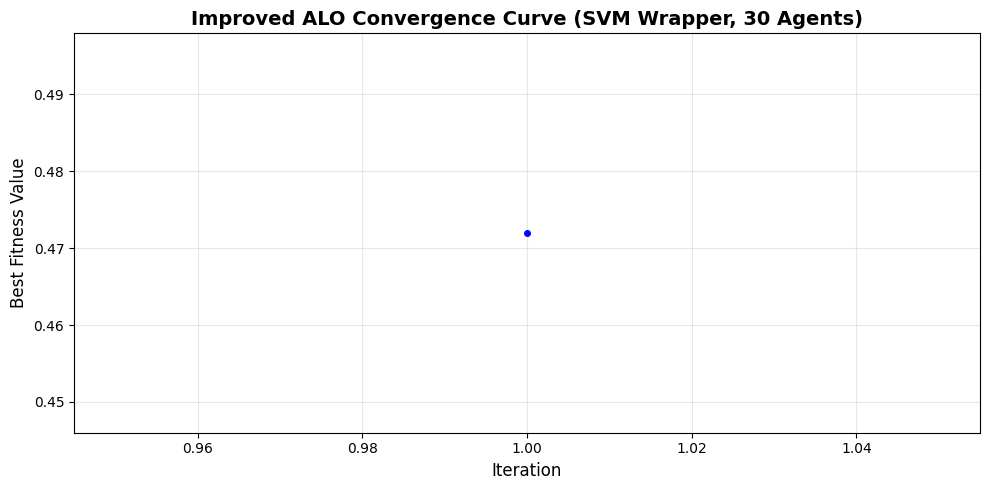

In [24]:
# ALO Convergence Curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(alo_curve)+1), alo_curve, 'b-o', linewidth=2, markersize=4)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Best Fitness Value", fontsize=12)
plt.title("Improved ALO Convergence Curve (SVM Wrapper, 30 Agents)",
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/alo_convergence.png', dpi=300, bbox_inches='tight')
plt.show()

## Stage 3: Classifier Evaluation on ALO-Selected Deep Features

Training **SVM, KNN, MLP, Random Forest, XGBoost** on the ALO-selected feature subset.
Each classifier evaluated with full metrics, confusion matrix, and One-vs-Rest ROC curves.

Train shape after ALO: (38232, 128)
Test shape after ALO : (9558, 128)
XGBoost available.

  SVM Performance (ALO-Selected Deep Features)
Accuracy              : 0.5184 (51.84%)
Precision (Macro)     : 0.5315
Precision (Weighted)  : 0.5315
Recall (Macro)        : 0.5184
Recall (Weighted)     : 0.5184
F1-Score (Macro)      : 0.5087
F1-Score (Weighted)   : 0.5087
Cohen's Kappa         : 0.3980

Classification Report:
              precision    recall  f1-score   support

       narco     0.4308    0.6627    0.5222      1912
         ins     0.5853    0.3789    0.4600      1911
        nfle     0.4175    0.3787    0.3971      1912
         plm     0.6192    0.7850    0.6923      1912
         rbd     0.6047    0.3867    0.4718      1911

    accuracy                         0.5184      9558
   macro avg     0.5315    0.5184    0.5087      9558
weighted avg     0.5315    0.5184    0.5087      9558



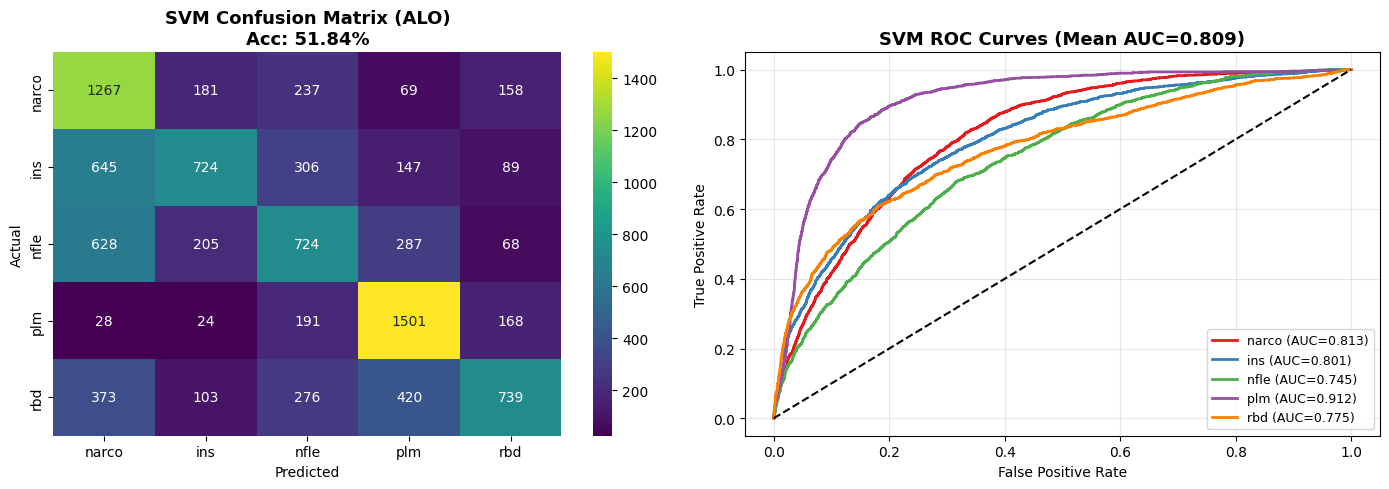


  KNN Performance (ALO-Selected Deep Features)
Accuracy              : 0.5056 (50.56%)
Precision (Macro)     : 0.5023
Precision (Weighted)  : 0.5023
Recall (Macro)        : 0.5056
Recall (Weighted)     : 0.5056
F1-Score (Macro)      : 0.5034
F1-Score (Weighted)   : 0.5034
Cohen's Kappa         : 0.3821

Classification Report:
              precision    recall  f1-score   support

       narco     0.4635    0.4718    0.4676      1912
         ins     0.5033    0.4757    0.4891      1911
        nfle     0.4138    0.4017    0.4076      1912
         plm     0.6307    0.7029    0.6649      1912
         rbd     0.5003    0.4762    0.4879      1911

    accuracy                         0.5056      9558
   macro avg     0.5023    0.5056    0.5034      9558
weighted avg     0.5023    0.5056    0.5034      9558



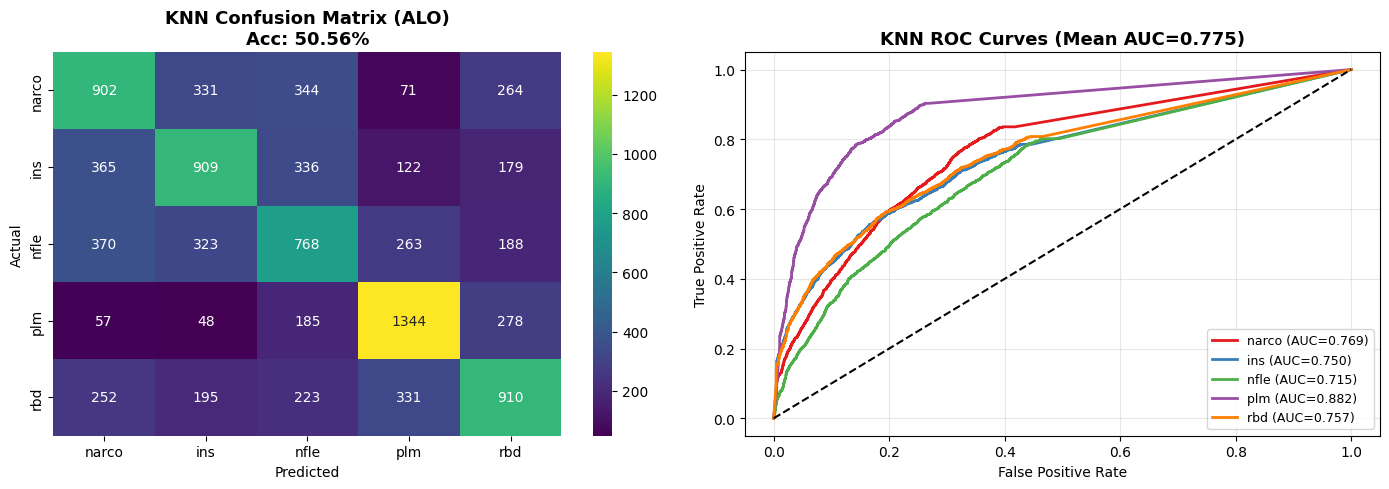


  MLP Performance (ALO-Selected Deep Features)
Accuracy              : 0.5793 (57.93%)
Precision (Macro)     : 0.5799
Precision (Weighted)  : 0.5799
Recall (Macro)        : 0.5793
Recall (Weighted)     : 0.5793
F1-Score (Macro)      : 0.5748
F1-Score (Weighted)   : 0.5748
Cohen's Kappa         : 0.4741

Classification Report:
              precision    recall  f1-score   support

       narco     0.5031    0.5941    0.5448      1912
         ins     0.5753    0.5495    0.5621      1911
        nfle     0.5399    0.4744    0.5050      1912
         plm     0.6549    0.8028    0.7213      1912
         rbd     0.6265    0.4757    0.5407      1911

    accuracy                         0.5793      9558
   macro avg     0.5799    0.5793    0.5748      9558
weighted avg     0.5799    0.5793    0.5748      9558



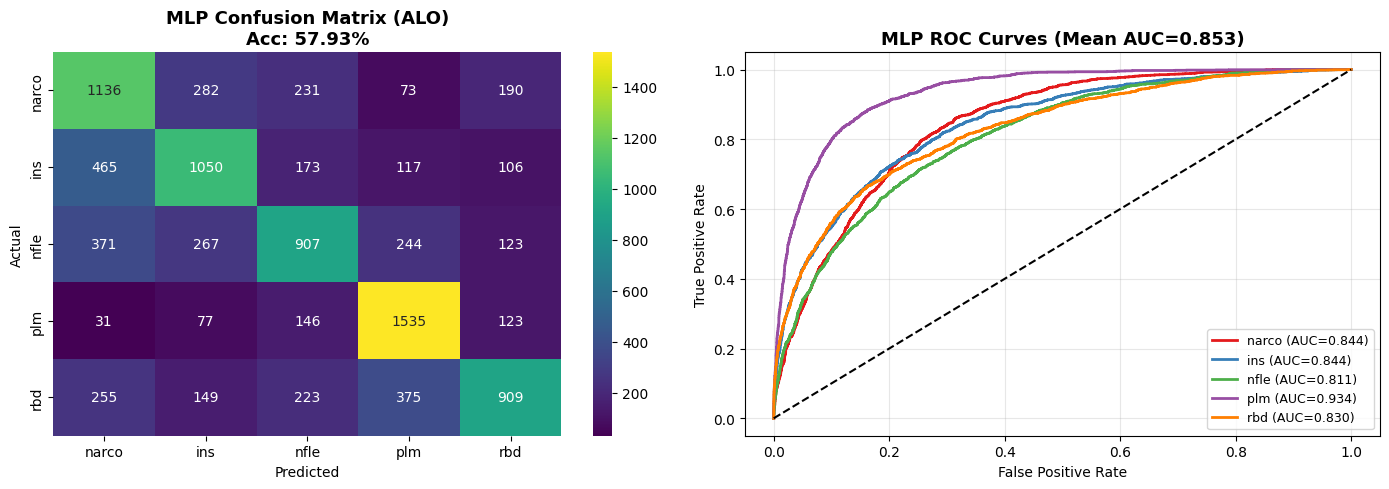


  RandomForest Performance (ALO-Selected Deep Features)
Accuracy              : 0.5512 (55.12%)
Precision (Macro)     : 0.5496
Precision (Weighted)  : 0.5496
Recall (Macro)        : 0.5512
Recall (Weighted)     : 0.5512
F1-Score (Macro)      : 0.5481
F1-Score (Weighted)   : 0.5481
Cohen's Kappa         : 0.4389

Classification Report:
              precision    recall  f1-score   support

       narco     0.4934    0.5821    0.5341      1912
         ins     0.5638    0.5060    0.5334      1911
        nfle     0.4642    0.4205    0.4413      1912
         plm     0.6524    0.7432    0.6949      1912
         rbd     0.5742    0.5039    0.5368      1911

    accuracy                         0.5512      9558
   macro avg     0.5496    0.5512    0.5481      9558
weighted avg     0.5496    0.5512    0.5481      9558



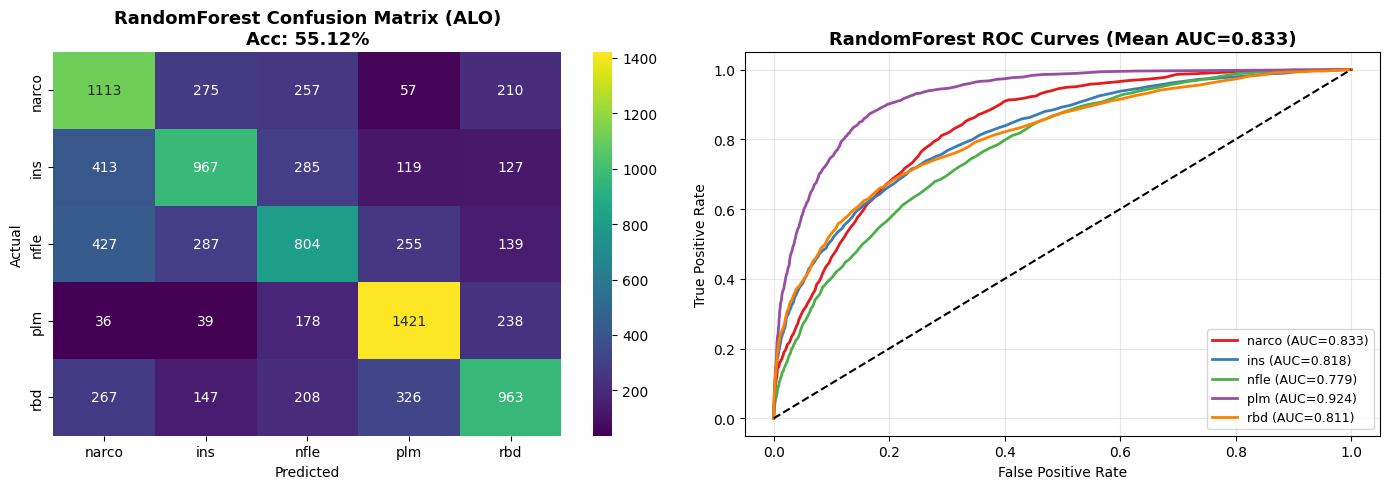


  XGBoost Performance (ALO-Selected Deep Features)
Accuracy              : 0.5510 (55.10%)
Precision (Macro)     : 0.5489
Precision (Weighted)  : 0.5489
Recall (Macro)        : 0.5509
Recall (Weighted)     : 0.5510
F1-Score (Macro)      : 0.5483
F1-Score (Weighted)   : 0.5483
Cohen's Kappa         : 0.4387

Classification Report:
              precision    recall  f1-score   support

       narco     0.4904    0.5622    0.5239      1912
         ins     0.5493    0.5217    0.5352      1911
        nfle     0.4723    0.4231    0.4463      1912
         plm     0.6615    0.7401    0.6986      1912
         rbd     0.5709    0.5076    0.5374      1911

    accuracy                         0.5510      9558
   macro avg     0.5489    0.5509    0.5483      9558
weighted avg     0.5489    0.5510    0.5483      9558



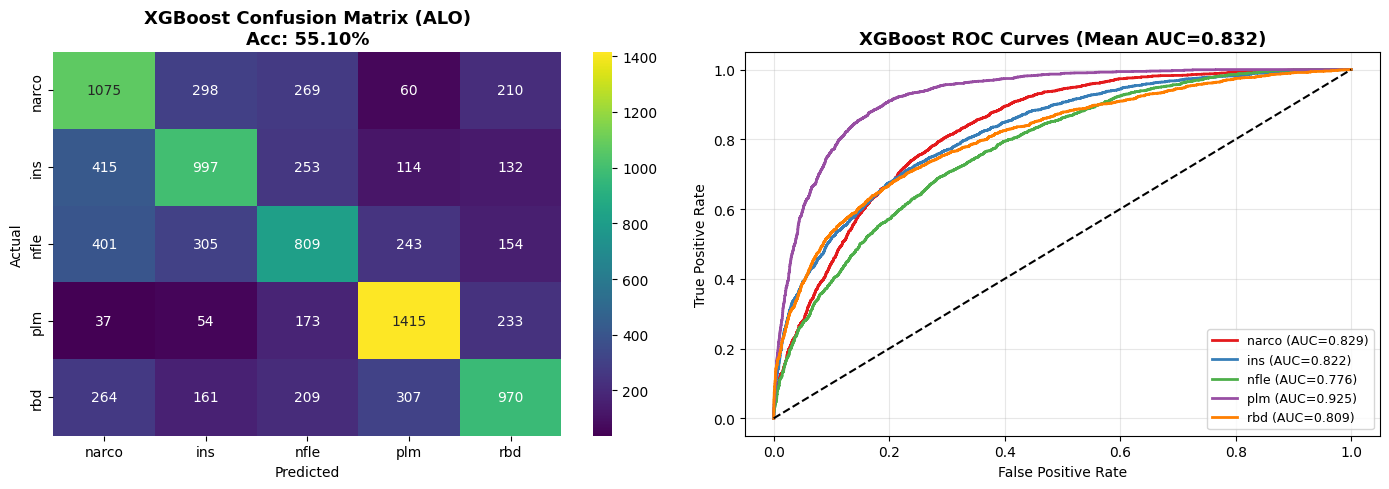


All classifiers evaluated!


In [26]:
# Apply ALO mask to deep features
X_train_alo = train_deep_scaled[:, best_mask]
X_test_alo = test_deep_scaled[:, best_mask]

print(f"Train shape after ALO: {X_train_alo.shape}")
print(f"Test shape after ALO : {X_test_alo.shape}")

# Define classifiers
classifiers = {
    "SVM": SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, weights='distance', metric='minkowski'),
    "MLP": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
}

# Try importing XGBoost
try:
    from xgboost import XGBClassifier
    classifiers["XGBoost"] = XGBClassifier(
        n_estimators=200, eval_metric='mlogloss',
        use_label_encoder=False, random_state=42
    )
    print("XGBoost available.")
except ImportError:
    print("XGBoost not available, skipping.")

# ROC preparation
classes = np.unique(y_train_int)
y_test_bin = label_binarize(y_test_int, classes=classes)
n_classes = y_test_bin.shape[1]

alo_results = {}

for name, clf in classifiers.items():

    print(f"\n{'='*70}")
    print(f"  {name} Performance (ALO-Selected Deep Features)")
    print(f"{'='*70}")

    clf.fit(X_train_alo, y_train_int)
    preds = clf.predict(X_test_alo)

    try:
        probs = clf.predict_proba(X_test_alo)
    except:
        probs = None

    acc = accuracy_score(y_test_int, preds)
    prec_macro = precision_score(y_test_int, preds, average='macro')
    prec_weighted = precision_score(y_test_int, preds, average='weighted')
    rec_macro = recall_score(y_test_int, preds, average='macro')
    rec_weighted = recall_score(y_test_int, preds, average='weighted')
    f1_macro = f1_score(y_test_int, preds, average='macro')
    f1_weighted = f1_score(y_test_int, preds, average='weighted')
    kappa = cohen_kappa_score(y_test_int, preds)

    alo_results[name] = {
        'accuracy': acc, 'precision_macro': prec_macro,
        'precision_weighted': prec_weighted,
        'recall_macro': rec_macro, 'recall_weighted': rec_weighted,
        'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
        'kappa': kappa, 'preds': preds, 'probs': probs
    }

    print(f"Accuracy              : {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision (Macro)     : {prec_macro:.4f}")
    print(f"Precision (Weighted)  : {prec_weighted:.4f}")
    print(f"Recall (Macro)        : {rec_macro:.4f}")
    print(f"Recall (Weighted)     : {rec_weighted:.4f}")
    print(f"F1-Score (Macro)      : {f1_macro:.4f}")
    print(f"F1-Score (Weighted)   : {f1_weighted:.4f}")
    print(f"Cohen's Kappa         : {kappa:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(y_test_int, preds, target_names=LABELS, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_test_int, preds)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
                xticklabels=LABELS, yticklabels=LABELS, ax=axes[0])
    axes[0].set_title(f'{name} Confusion Matrix (ALO)\nAcc: {acc*100:.2f}%',
                      fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    # ROC Curve
    if probs is not None:
        mean_auc = 0
        for i, (label, color) in enumerate(zip(LABELS, colors)):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
            roc_auc_val = auc(fpr, tpr)
            mean_auc += roc_auc_val
            axes[1].plot(fpr, tpr, lw=2, color=color,
                         label=f'{label} (AUC={roc_auc_val:.3f})')

        mean_auc /= n_classes
        axes[1].plot([0, 1], [0, 1], 'k--')
        axes[1].set_title(f'{name} ROC Curves (Mean AUC={mean_auc:.3f})',
                          fontsize=13, fontweight='bold')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'ROC not available', ha='center', va='center')

    plt.tight_layout()
    plt.savefig(f'artifacts/{name.lower()}_alo_evaluation.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\nAll classifiers evaluated!")

## Stage 4: Comprehensive Comparison


  FINAL COMPARISON: BASELINE vs ALO-IMPROVED
                    Model Accuracy Precision (Macro) Recall (Macro) F1-Score (Macro)  Kappa
Hybrid CNN-ViT (Baseline)   41.94%            35.23%         41.95%           37.35% 0.2743
                ALO + SVM   51.84%            53.15%         51.84%           50.87% 0.3980
                ALO + KNN   50.56%            50.23%         50.56%           50.34% 0.3821
                ALO + MLP   57.93%            57.99%         57.93%           57.48% 0.4741
       ALO + RandomForest   55.12%            54.96%         55.12%           54.81% 0.4389
            ALO + XGBoost   55.10%            54.89%         55.09%           54.83% 0.4387

Best Model: ALO + MLP
Best Accuracy: 57.93%
Improvement over baseline: +15.99%
Improvement over original ViT (82.12%): -24.19%


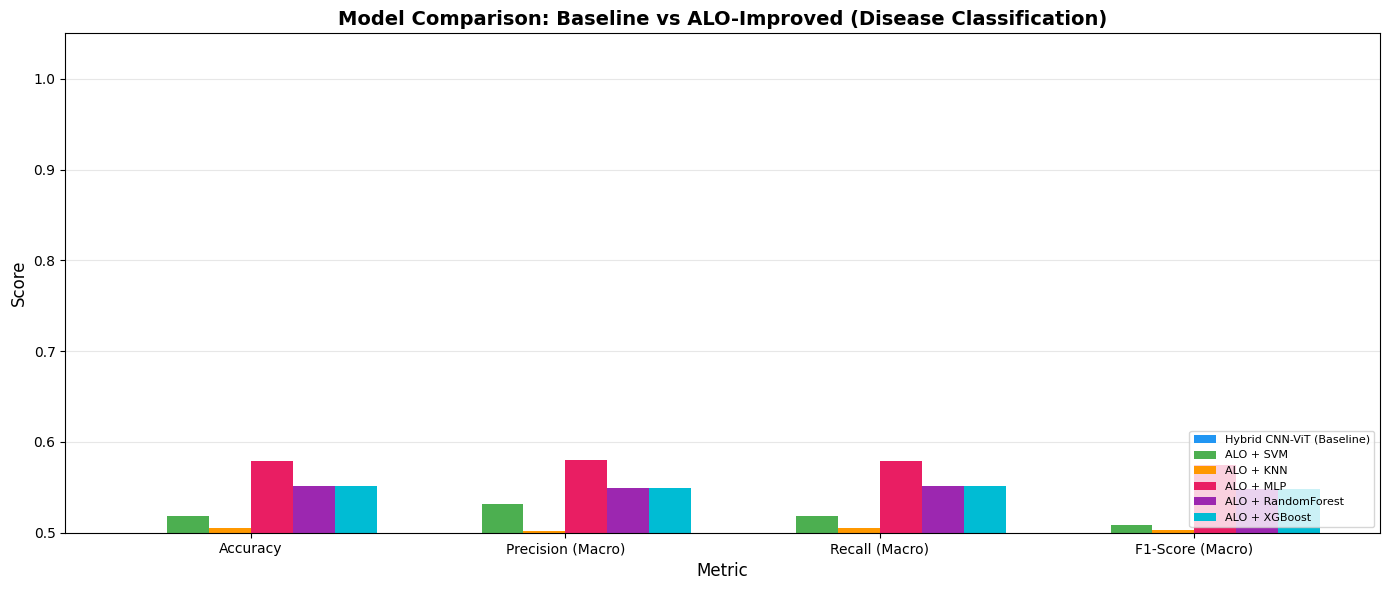

In [27]:
# =========================================================
# COMPARISON: Baseline CNN-ViT vs ALO + Classifiers
# =========================================================

comparison = {
    'Model': ['Hybrid CNN-ViT (Baseline)'],
    'Accuracy': [baseline_acc],
    'Precision (Macro)': [baseline_prec],
    'Recall (Macro)': [baseline_rec],
    'F1-Score (Macro)': [baseline_f1],
    'Kappa': [baseline_kappa]
}

for name, r in alo_results.items():
    comparison['Model'].append(f'ALO + {name}')
    comparison['Accuracy'].append(r['accuracy'])
    comparison['Precision (Macro)'].append(r['precision_macro'])
    comparison['Recall (Macro)'].append(r['recall_macro'])
    comparison['F1-Score (Macro)'].append(r['f1_macro'])
    comparison['Kappa'].append(r['kappa'])

comp_df = pd.DataFrame(comparison)

print("\n" + "=" * 100)
print("  FINAL COMPARISON: BASELINE vs ALO-IMPROVED")
print("=" * 100)

display_df = comp_df.copy()
for col in ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']:
    display_df[col] = display_df[col].apply(lambda x: f"{x*100:.2f}%")
display_df['Kappa'] = display_df['Kappa'].apply(lambda x: f"{float(x):.4f}")

print(display_df.to_string(index=False))
print("=" * 100)

# Highlight best model
best_idx = comp_df['Accuracy'].idxmax()
best_model_name = comp_df.loc[best_idx, 'Model']
best_acc = comp_df.loc[best_idx, 'Accuracy']
improvement = (best_acc - baseline_acc) * 100

print(f"\nBest Model: {best_model_name}")
print(f"Best Accuracy: {best_acc*100:.2f}%")
print(f"Improvement over baseline: {improvement:+.2f}%")
print(f"Improvement over original ViT (82.12%): {(best_acc*100 - 82.12):+.2f}%")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(14, 6))
metrics_to_plot = ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']
x = np.arange(len(metrics_to_plot))
n_models = len(comp_df)
width = 0.8 / n_models
chart_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']

for i, model_name in enumerate(comp_df['Model']):
    values = [comp_df.loc[i, m] for m in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=model_name,
           color=chart_colors[i % len(chart_colors)])

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Baseline vs ALO-Improved (Disease Classification)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(metrics_to_plot)
ax.legend(loc='lower right', fontsize=8)
ax.set_ylim(0.5, 1.05)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('artifacts/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
# =========================================================
# SAVE ALL ARTIFACTS
# =========================================================

# ALO artifacts
np.save('artifacts/alo_convergence_curve.npy', alo_curve)
np.save('artifacts/alo_best_mask.npy', best_mask)
np.save('artifacts/alo_best_position.npy', best_pos)
np.save('artifacts/training_history.npy', history.history)

# Comparison
comp_df.to_csv('artifacts/comparison_summary.csv', index=False)

# Per-classifier predictions
for name, r in alo_results.items():
    pred_data = {
        'True_Label': y_test_int,
        'True_Name': [LABELS[i] for i in y_test_int],
        'Predicted_Label': r['preds'],
        'Predicted_Name': [LABELS[i] for i in r['preds']],
    }
    if r['probs'] is not None:
        for idx, label in enumerate(LABELS):
            pred_data[f'Prob_{label}'] = r['probs'][:, idx]
    pd.DataFrame(pred_data).to_csv(f'artifacts/{name.lower()}_alo_predictions.csv', index=False)

# Baseline predictions
baseline_pred_data = {
    'True_Label': y_test_int,
    'True_Name': [LABELS[i] for i in y_test_int],
    'Predicted_Label': y_pred_baseline,
    'Predicted_Name': [LABELS[i] for i in y_pred_baseline],
}
for idx, label in enumerate(LABELS):
    baseline_pred_data[f'Prob_{label}'] = pred_prob_baseline[:, idx]
pd.DataFrame(baseline_pred_data).to_csv('artifacts/baseline_predictions.csv', index=False)

# Performance summary
best_alo_name = max(alo_results, key=lambda k: alo_results[k]['accuracy'])
best_alo_r = alo_results[best_alo_name]

summary_data = {
    'Metric': [
        'Baseline Accuracy', 'Best ALO Model', 'Best ALO Accuracy',
        'Improvement', 'Selected Features', 'Total Features',
        'Macro Precision', 'Macro Recall', 'Macro F1-Score',
        "Cohen's Kappa", 'Training Time (s)', 'Total Parameters'
    ],
    'Value': [
        f"{baseline_acc*100:.2f}%",
        f"ALO + {best_alo_name}",
        f"{best_alo_r['accuracy']*100:.2f}%",
        f"{(best_alo_r['accuracy'] - baseline_acc)*100:+.2f}%",
        str(np.sum(best_mask)),
        str(len(best_mask)),
        f"{best_alo_r['precision_macro']*100:.2f}%",
        f"{best_alo_r['recall_macro']*100:.2f}%",
        f"{best_alo_r['f1_macro']*100:.2f}%",
        f"{best_alo_r['kappa']:.4f}",
        f"{training_time:.1f}s",
        f"{model.count_params():,}",
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('artifacts/performance_summary.csv', index=False)

print("\n" + "=" * 60)
print("  FINAL PERFORMANCE SUMMARY")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)

# Save model
model.save('artifacts/hybrid_cnn_vit_disease_alo_final.h5')

print("\nAll artifacts saved to artifacts/ directory!")


  FINAL PERFORMANCE SUMMARY
           Metric     Value
Baseline Accuracy    41.94%
   Best ALO Model ALO + MLP
Best ALO Accuracy    57.93%
      Improvement   +15.99%
Selected Features       128
   Total Features       256
  Macro Precision    57.99%
     Macro Recall    57.93%
   Macro F1-Score    57.48%
    Cohen's Kappa    0.4741
Training Time (s)   2345.6s
 Total Parameters   851,333

All artifacts saved to artifacts/ directory!
